## <span style="color:#db7d60">Setup</span>

In [24]:
%load_ext autoreload
%autoreload 2

import json
import math
import pickle
import numpy as np
import pandas as pd
import textwrap
import sys
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

from matplotlib.ticker import ScalarFormatter, FuncFormatter

import pUtil
from analysis_common import *
import data_manager
import analysis as anal

import vector
from particle import Particle
from particle import PDGID

plt.rcParams['figure.figsize'] = (21, 6)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# ---- Global seaborn style ----
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.1
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def set_pub_style(*, context="paper", font="serif", base_fontsize=10, dpi=200, use_tex=False):   # set True if you have a working LaTeX install
    # Seaborn baseline
    sns.set_theme(context=context, style="ticks")

    # Colorblind-friendly palette (great default for journals)
    sns.set_palette("colorblind")

    # Matplotlib rcParams tuned for print
    mpl.rcParams.update({
        # Figure + save
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.bbox": "tight",
        "savefig.transparent": True,   # keeps backgrounds clean in PDFs
        "pdf.fonttype": 42,            # embed TrueType fonts
        "ps.fonttype": 42,

        # Typography
        "font.family": font,
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "axes.labelsize": base_fontsize + 1,
        "xtick.labelsize": base_fontsize,
        "ytick.labelsize": base_fontsize,
        "legend.fontsize": base_fontsize,
        "legend.title_fontsize": base_fontsize,

        # Axes + lines
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "lines.markersize": 5,

        # Ticks (major + minor)
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,

        # Grid (usually off for journal plots; enable per-figure if needed)
        "axes.grid": False,

        # Legend
        "legend.frameon": False,

        # Math text
        "mathtext.fontset": "stix",
        "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
        "text.usetex": use_tex,
    })

    # Remove top/right spines for a clean physics look
    sns.despine(trim=True)

set_pub_style(base_fontsize=10, dpi=250, use_tex=False)

<Figure size 5250x1500 with 0 Axes>

## <span style="color:#db7d60">Analysis</span>

In [67]:
anal.plotting.default_figsize = (6, 5)  # single-column friendly
anal.plotting.default_dpi = 100
# Custom formatter to force scientific notation for small numbers
def sci_notation(x, pos):
    return f'{x:.0e}'

def rescale_yaxis_to_order_of_magnitude(ax, values, label="Counts"):
    """
    Dynamically rescales y-axis to nearest power of 10.
    Example:
        750000 -> axis shows 7.5 and label says Counts (×10^5)
    """

    max_val = np.nanmax(values)
    if max_val <= 0:
        return

    # Determine order of magnitude
    order = int(np.floor(np.log10(max_val)))
    scale = 10 ** order

    # Formatter: divide ticks by scale
    formatter = FuncFormatter(lambda y, _: f"{y/scale:.0f}")
    ax.yaxis.set_major_formatter(formatter)

    # Update axis label
    ax.set_ylabel(f"{label} (×10$^{{{order}}}$)")
    
# IMPORTANT: This function assumes ALL provided models are from the same dataset!!!!
@staticmethod
def compare_distributions_all(
    model_names,
    model_legend_title,
    column_name=None,
    normalized=False,
    use_log=False,
    out_file=None,
    ratio_ylim=(0.5, 1.5),
    ratio_bands=(0.05, 0.10, 0.20),
):
    """
    Top: Geant4 + generated distributions with Poisson stat error bars
    Bottom: ratio (Generated / Geant4) computed using *densities* (shape comparison)

    Notes:
      - If normalized=False: top shows counts; errors are sqrt(counts)
      - If normalized=True: top shows probability density; errors are propagated from Poisson
      - Ratio panel always uses densities (independent of total N)
    """
    # ---- seaborn styling (uses whatever theme you've set globally) ----
    sns.set_theme(style="ticks", context="paper")
    palette = sns.color_palette("colorblind", n_colors=max(3, len(model_names) + 1))

    unit = ''
    if column_name in ['e', 'pt', 'px', 'py', 'pz']:
        unit = '[MeV]'

    lab = column_name
    if column_name == 'pt':
        lab = '$ p_T $'
    if column_name == 'eta':
        lab = '$ \eta $'
    elif column_name == 'theta':
        lab = '$ \theta $'
    elif column_name == 'phi':
        lab = '$ \phi $'

    # ---- figure layout: 2 rows (distribution + ratio) ----
    fig, (axd, axr) = plt.subplots(
        2, 1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        constrained_layout=True,
        dpi=anal.plotting.default_dpi
    )

    # Titles/labels (journal style: keep title modest; you can also remove and rely on caption)
    # Paper plots do not have titles!!
    # fig.suptitle(f'{lab} Distribution (All Outgoing Particles)', fontsize=12) 
    axd.set_ylabel('log(Frequency)' if use_log else ('Density' if normalized else 'Counts'))
    axr.set_ylabel('Gen / Geant4')
    axr.set_xlabel(f'{lab} {unit}')

    axd.set_yscale('log' if use_log else 'linear')

    # Minor ticks + physics-like ticks
    for ax in (axd, axr):
        ax.minorticks_on()
        ax.tick_params(which='both', direction='in', top=True, right=True)

    # ---- common bins/range (from first model) ----
    bin_settings = anal.plotting.get_common_data(model_names[0])
    x_min = bin_settings[column_name]['min']
    x_max = bin_settings[column_name]['max']
    n_bins = bin_settings[column_name]['bins']

    edges = np.linspace(x_min, x_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    relevant_column_pos = anal.plotting.verbose_columns.index(column_name)

    # ---- load real (Geant4) ----
    real_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_model_preparation_dir(model_names[0]) / 'real_verbose_test_particles.csv',
        pad_token=np.nan
    )
    real_vals = []
    for event in real_verbose_data:
        for particle in event[1:]:
            v = particle[relevant_column_pos]
            if not np.isnan(v):
                real_vals.append(v)
    real_vals = np.asarray(real_vals)

    # Histogram counts (always compute raw counts; we can convert to density ourselves)
    rcounts, _ = np.histogram(real_vals, bins=edges)
    rN = np.sum(rcounts)

    # Convert to what we plot on top axis
    if normalized:
        # probability density: counts / (N * bin_width)
        r_y = rcounts / (rN * widths) if rN > 0 else np.zeros_like(rcounts, dtype=float)
        r_err = np.sqrt(rcounts) / (rN * widths) if rN > 0 else np.zeros_like(rcounts, dtype=float)
    else:
        r_y = rcounts.astype(float)
        r_err = np.sqrt(rcounts)

    # Plot Geant4
    axd.stairs(
        r_y, edges,
        label=f'{model_legend_title[0]} | N={rN}',
        linewidth=2.2,
        color="black",
        zorder=3
    )
        
    # Error bars (skip empty bins)
    mask_r = rcounts > 0
    axd.errorbar(
        centers[mask_r], r_y[mask_r], yerr=r_err[mask_r],
        fmt='none', ecolor='black', elinewidth=0.9, capsize=0, alpha=0.9, zorder=4
    )

    # For ratio: always use densities (shape-only)
    r_density = rcounts / rN if rN > 0 else np.zeros_like(rcounts, dtype=float)
    r_density_err = np.sqrt(rcounts) / rN if rN > 0 else np.zeros_like(rcounts, dtype=float)

    # ---- generated per model ----
    for idx, model_name in enumerate(model_names):
        sampled_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_latest_sampling_dir(model_name) / 'untokenized_samples_verbose.csv',
            pad_token=np.nan
        )

        gen_vals = []
        for event in sampled_verbose_data:
            for particle in event[1:]:
                v = particle[relevant_column_pos]
                if not np.isnan(v):
                    gen_vals.append(v)
        gen_vals = np.asarray(gen_vals)

        gcounts, _ = np.histogram(gen_vals, bins=edges)
        gN = np.sum(gcounts)

        # Top panel values
        if normalized:
            g_y = gcounts / (gN * widths) if gN > 0 else np.zeros_like(gcounts, dtype=float)
            g_err = np.sqrt(gcounts) / (gN * widths) if gN > 0 else np.zeros_like(gcounts, dtype=float)
        else:
            g_y = gcounts.astype(float)
            g_err = np.sqrt(gcounts)

        color = palette[idx + 1] if idx + 1 < len(palette) else anal.plotting.colors[idx]

        axd.stairs(
            g_y, edges,
            label=f'{model_legend_title[idx + 1]} | N={gN}',
            linewidth=2.0,
            color=color,
            zorder=2
        )
        mask_g = gcounts > 0
        axd.errorbar(
            centers[mask_g], g_y[mask_g], yerr=g_err[mask_g],
            fmt='none', ecolor=color, elinewidth=0.8, capsize=0, alpha=0.9, zorder=3
        )
        
        if not normalized:
            # Collect all plotted y values (real + generated)
            all_y_vals = [r_y]
            for idx, model_name in enumerate(model_names):
                all_y_vals.append(g_y)

            all_y_vals = np.concatenate(all_y_vals)
            rescale_yaxis_to_order_of_magnitude(axd, all_y_vals, label="Counts")

        # Ratio panel: use densities (probabilities) regardless of normalized flag
        g_density = gcounts / gN if gN > 0 else np.zeros_like(gcounts, dtype=float)
        g_density_err = np.sqrt(gcounts) / gN if gN > 0 else np.zeros_like(gcounts, dtype=float)

        ratio = np.divide(g_density, r_density, out=np.full_like(g_density, np.nan, dtype=float), where=r_density > 0)

        # Optional: ratio uncertainty via propagation
        # ratio_err = ratio * sqrt( (dg/g)^2 + (dr/r)^2 )
        ratio_err = np.full_like(ratio, np.nan, dtype=float)
        ok = (g_density > 0) & (r_density > 0)
        ratio_err[ok] = ratio[ok] * np.sqrt(
            (g_density_err[ok] / g_density[ok])**2 + (r_density_err[ok] / r_density[ok])**2
        )

        axr.stairs(ratio, edges, linewidth=1.6, color=color, zorder=2)
        # error bars (skip NaNs)
        ok2 = np.isfinite(ratio) & np.isfinite(ratio_err)
        axr.errorbar(
            centers[ok2], ratio[ok2], yerr=ratio_err[ok2],
            fmt='none', ecolor=color, elinewidth=0.8, capsize=0, alpha=0.9, zorder=3
        )

    # Ratio bands around 1
    axr.axhline(1.0, color="0.35", lw=1.0)
    for frac in ratio_bands:
        axr.axhline(1.0 + frac, color="0.6", linestyle="--", lw=0.9)
        axr.axhline(1.0 - frac, color="0.6", linestyle="--", lw=0.9)
    axr.set_ylim(*ratio_ylim)

    # Legend: keep clean
    axd.legend(loc='upper right', frameon=False)

    # Clean spines (seaborn look)
    sns.despine(ax=axd, trim=True)
    sns.despine(ax=axr, trim=True)

    if out_file is not None:
        # Strongly recommend PDF for publication
        fig.savefig(out_file, bbox_inches='tight')
    plt.show()

    return fig, (axd, axr)

@staticmethod
def plot_validation_run(model_names, model_legend_title, y_lim=None, x_lim=None, use_log=False, out_file=None, plot_lr_schedule=False):
    if not isinstance(model_names, list):
        model_names = [model_names]

    fig, ax = plt.subplots(figsize=(20, 6), dpi=anal.plotting.default_dpi)

    if len(model_names) < 3:
        ax.set_title(f'Training Progress for {model_names}', fontsize=16)
    else:
        ax.set_title('Training Progress for various models', fontsize=16)

    ax.set_xlabel("Iteration", fontsize=16)
    ax.set_ylabel("Val Loss", fontsize=16)
    ax.tick_params(labelsize=14)

    if y_lim is not None:
        ax.set_ylim(y_lim)
    if x_lim is not None:
        ax.set_xlim(x_lim)
    if use_log:
        ax.set_yscale('log')

    # Optional LR axis (still matplotlib, styled consistently)
    lrax = None

    for idx, model_name in enumerate(model_names):
        model_data = anal.tables.get_all_data(model_name)
        min_val_row = model_data.checkpointed_df.loc[model_data.checkpointed_df['val_loss'].idxmin()]
        final_row = model_data.running_df.iloc[-1]

        if plot_lr_schedule:
            config_filepath = pUtil.get_model_config_filepath(model_name)
            with open(config_filepath, 'r') as f:
                model_config = json.load(f)
                training_conf = model_config.get('training_config', {})
                lr_scheduler = training_conf.get('lr_scheduler', 'cosine_annealing_with_warmup')
                warmup_iters = training_conf.get('warmup_iters', 0)
                lr_decay_iters = training_conf.get('lr_decay_iters', 0)
                learning_rate = training_conf.get('learning_rate', 0)
                min_lr = training_conf.get('min_lr', 0)
                base_lr_decay_mult = training_conf.get('base_lr_decay_mult', 1)
                cycle_steps_mult = training_conf.get('cycle_steps_mult', 1)

            iters = np.arange(model_data.running_df['iter'].max())
            lrs = [
                anal.plotting._get_lr(it, lr_scheduler, warmup_iters, lr_decay_iters,
                                     min_lr, learning_rate, cycle_steps_mult, base_lr_decay_mult)
                for it in iters
            ]

            if lrax is None:
                lrax = ax.twinx()
                lrax.set_ylabel("Learning rate", fontsize=16)
                lrax.tick_params(axis='y', labelsize=14)

            # seaborn lineplot for LR (but on the twin axis)
            sns.lineplot(x=iters, y=lrs, ax=lrax, linewidth=1, label="Learning rate")
            lrax.yaxis.set_major_formatter(FuncFormatter(sci_notation))

        # seaborn lineplot for val loss
        sns.lineplot(
            x=model_data.running_df['iter'],
            y=model_data.running_df['val_loss'],
            ax=ax,
            linewidth=2,
            color=anal.plotting.colors[idx],
            label=model_legend_title[idx],
        )

        # Annotation near last point
        ax.annotate(
            model_legend_title[idx],
            xy=(final_row['iter'], final_row['val_loss']),
            xytext=(final_row['iter'] * 1.005, final_row['val_loss'] - 0.02),
            fontsize=14,
            color=anal.plotting.colors[idx]
        )

    ax.minorticks_on()
    ax.tick_params(which='both', top=True, right=True)
    ax.grid(True)

    # Put legend outside like you had
    ax.legend(loc='center right', fontsize=14)
    fig.tight_layout()

    if out_file is not None:
        fig.savefig(out_file, bbox_inches='tight', dpi=anal.plotting.default_dpi)

    plt.show()
    return fig, ax

<>:62: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\e'
<>:66: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_694365/265481650.py:62: SyntaxWarning: invalid escape sequence '\e'
  lab = '$ \eta $'
/tmp/ipykernel_694365/265481650.py:66: SyntaxWarning: invalid escape sequence '\p'
  lab = '$ \phi $'


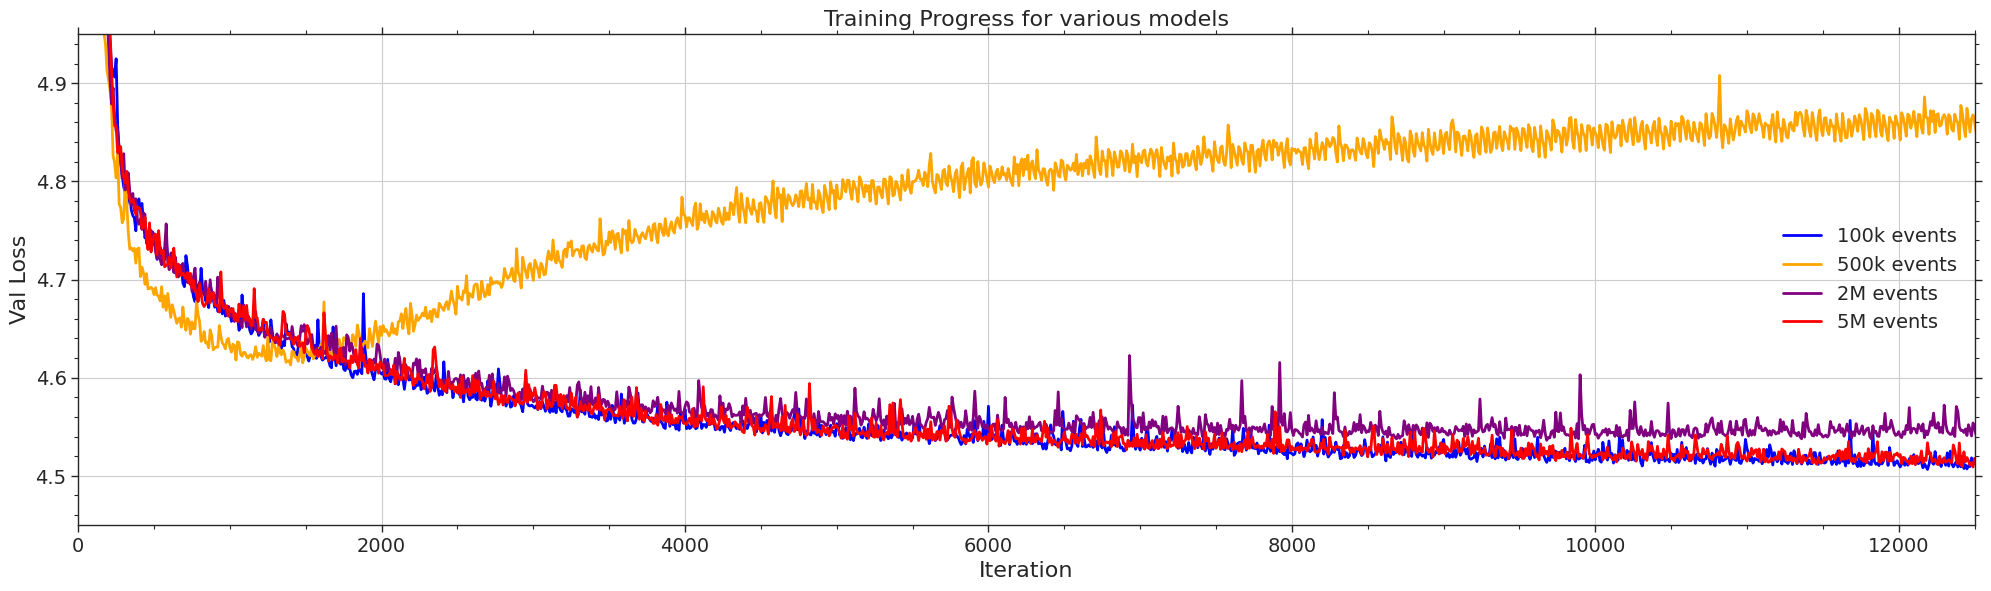

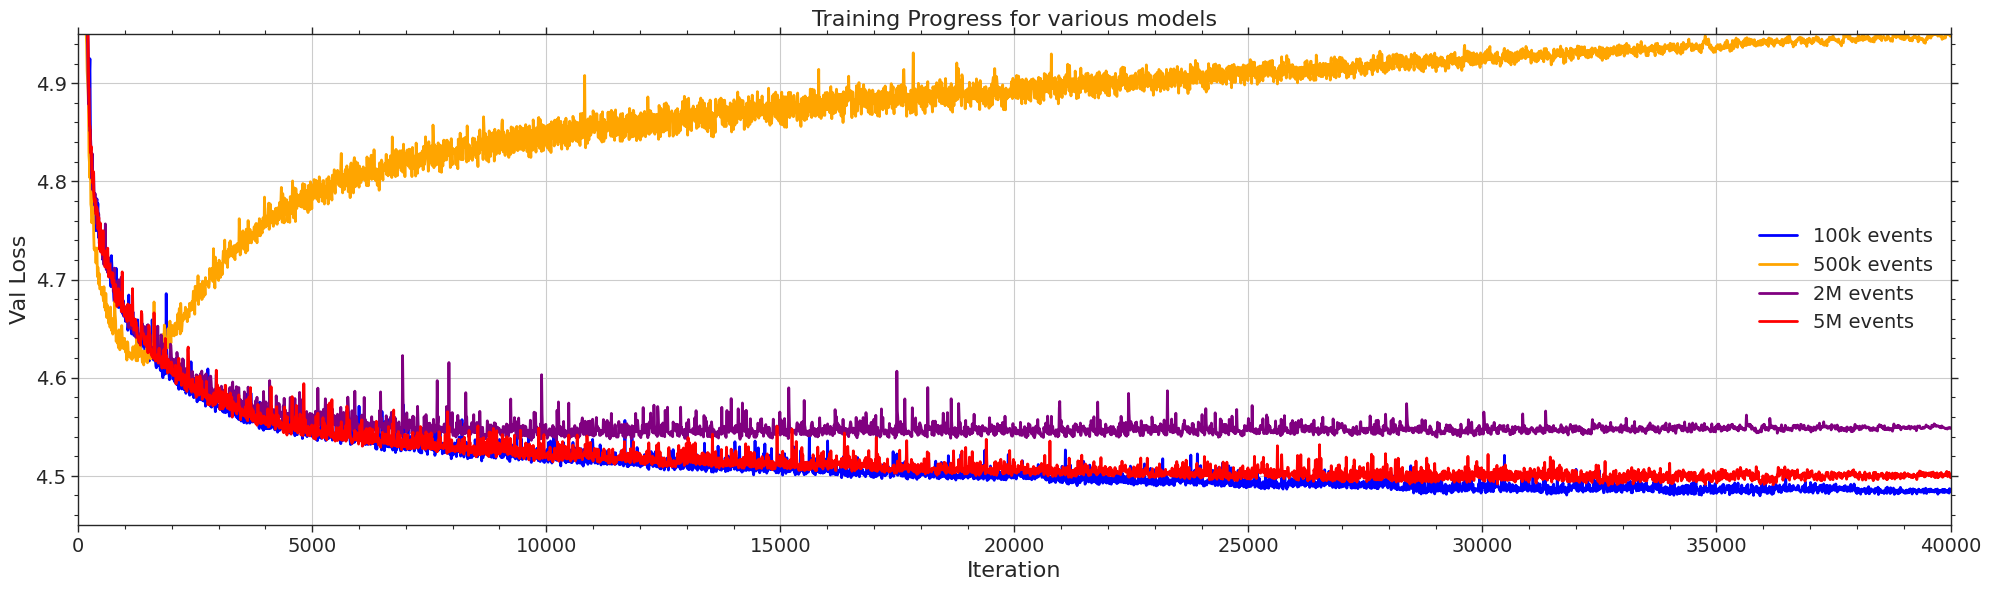

(<Figure size 2000x600 with 1 Axes>,
 <Axes: title={'center': 'Training Progress for various models'}, xlabel='Iteration', ylabel='Val Loss'>)

In [61]:
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']

plot_validation_run(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 12500))
plot_validation_run(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 40000))

pt


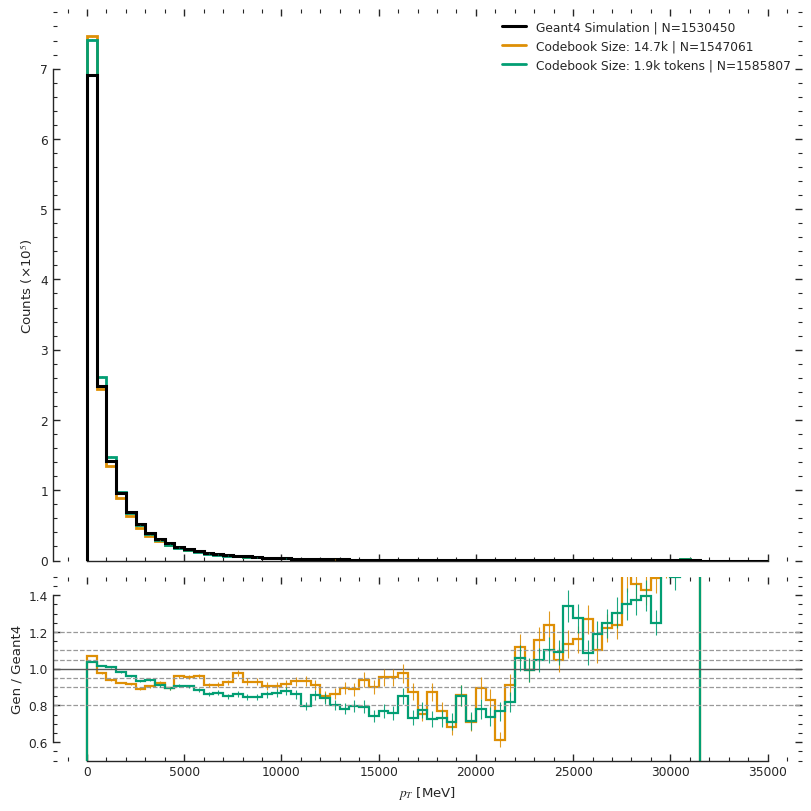

In [ ]:
all_columns = ["pt", "eta", "phi"]
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']
models_legend_title = ['Geant4 Simulation', 'Codebook Size: 14.7k', 'Codebook Size: 1.9k tokens']
for column in all_columns:
    print(column)
    compare_distributions_all(models_to_compare, models_legend_title, column, normalized=False, use_log=False, out_file=parent_dir / 'temp' / f"poster_all_{column}.png")
    compare_distributions_leading(models_to_compare, models_legend_title, column, normalized=False, use_log=False, out_file=parent_dir / 'temp' / f"poster_leading_{column}.png")
    # compare_distributions_leading(models_to_compare, models_legend_title, column, normalized=False, use_log=True, out_file=parent_dir / 'temp' / f"poster_leading_log_{column}.png")